In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [30]:
import os

PROJECT_DIR = "/content/drive/MyDrive/skripsi_nau"

os.chdir(PROJECT_DIR)

print(os.getcwd())

/content/drive/MyDrive/skripsi_nau


In [31]:
os.listdir()

['dataset',
 'notebook',
 'output',
 'model',
 'metadata',
 'embeddings',
 'faiss_index']

In [32]:
metadata = pd.read_csv("/content/drive/MyDrive/skripsi_nau/metadata/naudataset.csv")

metadata.head()

,id,nama_gambar,aktivitas,warna_dominan,hijab,undertone
0,1,img0001.jpg,coffee_shop_hopping,beige,ya,neutral
1,2,img0002.jpg,coffee_shop_hopping,beige,ya,neutral
2,3,img0003.jpg,coffee_shop_hopping,beige,ya,neutral
3,4,img0004.jpg,coffee_shop_hopping,beige,ya,neutral
4,5,img0005.jpg,coffee_shop_hopping,beige,ya,neutral


In [33]:
metadata.info()
metadata.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6609 entries, 0 to 6608
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             6609 non-null   int64 
 1   nama_gambar    6609 non-null   object
 2   aktivitas      6609 non-null   object
 3   warna_dominan  6609 non-null   object
 4   hijab          6609 non-null   object
 5   undertone      6609 non-null   object
dtypes: int64(1), object(5)
memory usage: 309.9+ KB


,id,nama_gambar,aktivitas,warna_dominan,hijab,undertone
count,6609.000000,6609,6609,6609,6609,6609
unique,NaN,6609,5,17,2,3
top,NaN,img6609.jpg,gym_to_caffe,beige,tidak,cool
freq,NaN,1,1538,765,4320,3384
mean,3305.000000,NaN,NaN,NaN,NaN,NaN
std,1907.998297,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,1653.000000,NaN,NaN,NaN,NaN,NaN
50%,3305.000000,NaN,NaN,NaN,NaN,NaN
75%,4957.000000,NaN,NaN,NaN,NaN,NaN


In [34]:
metadata.isnull().sum()

,0
id,0
nama_gambar,0
aktivitas,0
warna_dominan,0
hijab,0
undertone,0


In [35]:
print("Jumlah Outfit :", len(metadata))

Jumlah Outfit : 6609


In [36]:
metadata["aktivitas"].value_counts()


,count
aktivitas,
gym_to_caffe,1538
coffee_shop_hopping,1460
smart_casual,1331
dinner,1258
hiking,1022


In [37]:
metadata["undertone"].value_counts()

,count
undertone,
cool,3384
neutral,2157
warm,1068


In [38]:
metadata["hijab"].value_counts()

,count
hijab,
tidak,4320
ya,2289


In [39]:
folder = "dataset"

for filename in os.listdir(folder):
    old_path = os.path.join(folder, filename)

    # Pisahkan nama file dan ekstensi
    name, ext = os.path.splitext(filename)

    # Semua ekstensi dijadikan .jpg
    new_name = name + ".jpg"
    new_path = os.path.join(folder, new_name)

    # Rename jika berbeda
    if old_path != new_path:
        os.rename(old_path, new_path)

print("Semua ekstensi berhasil dinormalisasi menjadi .jpg")

Semua ekstensi berhasil dinormalisasi menjadi .jpg


In [42]:
sample = metadata.iloc[5490]

sample

,5490
id,5491
nama_gambar,img5491.jpg
aktivitas,coffee_shop_hopping
warna_dominan,emerald
hijab,ya
undertone,cool


(np.float64(-0.5), np.float64(637.5), np.float64(1199.5), np.float64(-0.5))

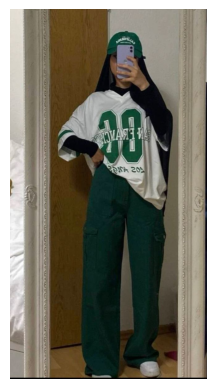

In [43]:
image_path = os.path.join(
    "dataset",
    sample["nama_gambar"]
)

img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")